<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Hands-on Practice Lab: Data Wrangling</h1>


### Importing Required Libraries


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Load the Dataset</h1>

In [58]:
filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"
df = pd.read_csv(filepath)

In [59]:
print(df.shape)
df.head()

(238, 13)


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


**Update the `Screen_Size_cm` column such that all values are rounded to nearest 2 decimal places by using `numpy.round()`**


In [60]:
df['Screen_Size_cm'] = np.round(df['Screen_Size_cm'],2)
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Task - 1: Evaluate the dataset for missing data</h1>

In [61]:
# Write your code below and press Shift+Enter to execute 
df.isna().sum()

Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
dtype: int64

<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Task - 2: Replace missing values with mean</h1>


In [62]:
# Write your code below and press Shift+Enter to execute
df["Screen_Size_cm"] = df["Screen_Size_cm"].replace(np.nan,df["Screen_Size_cm"].astype("float").mean(axis=0))
df["Weight_kg"] = df["Weight_kg"].replace(np.nan, df["Weight_kg"].astype("float").mean(axis=0))

df.isna().sum()

Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    0
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         0
Price             0
dtype: int64

<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Task - 3: Data Standardization</h1>
The value of Screen_size usually has a standard unit of inches. Similarly, weight of the laptop is needed to be in pounds. Use the below mentioned units of conversion and write a code to modify the columns of the dataframe accordingly. Update their names as well.

```{math}
1 inch = 2.54 cm
1 kg   = 2.205 pounds
```


In [63]:
# Write your code below and press Shift+Enter to execute
df["Screen_Size_cm"] = df["Screen_Size_cm"]/ 2.54
df.rename(columns={"Screen_Size_cm": "Screen_Size_inch"}, inplace=True)

df["Weight_kg"] = df[ "Weight_kg"]*2.205
df.rename(columns={"Weight_kg": "Weight_pound"}, inplace=True)

df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pound,Price
0,0,Acer,4,IPS Panel,2,1,5,14.000000,1.6,8,256,3.52800,978
1,1,Dell,3,Full HD,1,1,3,15.598425,2.0,4,256,4.85100,634
2,2,Dell,3,Full HD,1,1,7,15.598425,2.7,8,256,4.85100,946
3,3,Dell,4,IPS Panel,2,1,5,13.299213,1.6,8,128,2.69010,1244
4,4,HP,4,Full HD,2,1,7,15.598425,1.8,8,256,4.21155,837


<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Task-4: Data Normalization</h1>
Often it is required to normalize a continuous data attribute. Write a code to normalize the "CPU_frequency" attribute with respect to the maximum value available in the dataset.


In [64]:
# Write your code below and press Shift+Enter to execute
df["CPU_frequency"]=df["CPU_frequency"]/df["CPU_frequency"].max()
df["CPU_frequency"]

0      0.551724
1      0.689655
2      0.931034
3      0.551724
4      0.620690
         ...   
233    0.896552
234    0.827586
235    0.896552
236    0.862069
237    0.793103
Name: CPU_frequency, Length: 238, dtype: float64

<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Task - 5: Binning</h1>
Binning is a process of creating a categorical attribute which splits the values of a continuous data into a specified number of groups. In this case, write a code to create 3 bins for the attribute "Price". These bins would be named "Low", "Medium" and "High". The new attribute will be named "Price-binned".


Text(0.5, 1.0, 'Price data')

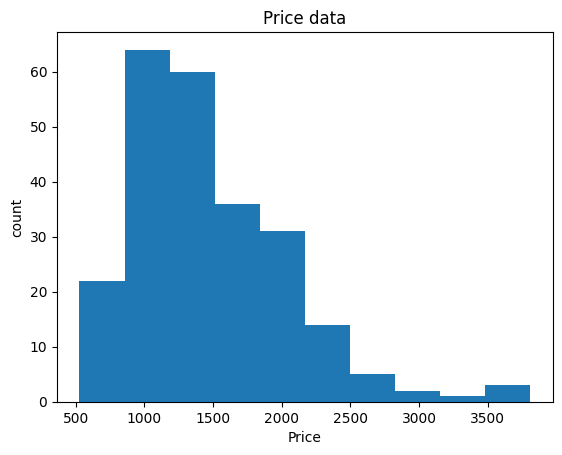

In [65]:
# Write your code below and press Shift+Enter to execute
plt.hist(df["Price"])

plt.xlabel("Price")
plt.ylabel("count")
plt.title("Price data")

In [66]:
bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)
labels= ['Low', 'Medium', 'High']
df['Price_binned']= pd.cut(df['Price'], bins, labels=labels)
df[["Price", 'Price_binned']].head(10)

,Price,Price_binned
0,978,Low
1,634,Low
2,946,Low
3,1244,Low
4,837,Low
5,1016,Low
6,1117,Low
7,866,Low
8,812,Low
9,1068,Low


Also, plot the bar graph of these bins.


Text(0.5, 1.0, 'Price_binned data')

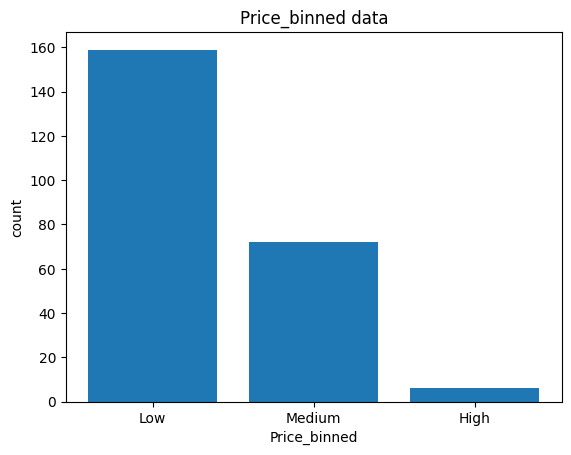

In [67]:
# Write your code below and press Shift+Enter to execute
plt.bar(labels, df["Price_binned"].value_counts())

plt.xlabel("Price_binned")
plt.ylabel("count")
plt.title("Price_binned data")

<details>
    <summary>Click here for Solution</summary>

```python
plt.bar(group_names, df["Price-binned"].value_counts())
plt.xlabel("Price")
plt.ylabel("count")
plt.title("Price bins")
```
</details>


<h1 style="color:white;font-weight: bold;text-align: center;background: linear-gradient(to right, #a6c0fe, #f68084);">Task - 6: Indicator variables</h1>
Convert the "Screen" attribute of the dataset into 2 indicator variables, "Screen-IPS_panel" and "Screen-Full_HD". Then drop the "Screen" attribute from the dataset.


In [68]:
# Write your code below and press Shift+Enter to execute
df.head()
dummy_var_screen = pd.get_dummies(df["Screen"])
dummy_var_screen.rename(columns={"Full HD": "Screen Full HD", "IPS Pannel": "Screen IPS Pannel"}, inplace=True)
dummy_var_screen.head()


,Screen Full HD,IPS Panel
0,False,True
1,True,False
2,True,False
3,False,True
4,True,False


In [69]:
if "Screen Full HD" not in df.columns:
    df= pd.concat([df, dummy_var_screen], axis= 1)
    df.drop("Screen", axis=1, inplace=True)
df.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pound,Price,Price_binned,Screen Full HD,IPS Panel
0,0,Acer,4,2,1,5,14.000000,0.551724,8,256,3.52800,978,Low,False,True
1,1,Dell,3,1,1,3,15.598425,0.689655,4,256,4.85100,634,Low,True,False
2,2,Dell,3,1,1,7,15.598425,0.931034,8,256,4.85100,946,Low,True,False
3,3,Dell,4,2,1,5,13.299213,0.551724,8,128,2.69010,1244,Low,False,True
4,4,HP,4,2,1,7,15.598425,0.620690,8,256,4.21155,837,Low,True,False


In [70]:
print(df.head())

   Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  Screen_Size_inch  \
0           0         Acer         4    2   1         5         14.000000   
1           1         Dell         3    1   1         3         15.598425   
2           2         Dell         3    1   1         7         15.598425   
3           3         Dell         4    2   1         5         13.299213   
4           4           HP         4    2   1         7         15.598425   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_pound  Price Price_binned  \
0       0.551724       8             256       3.52800    978          Low   
1       0.689655       4             256       4.85100    634          Low   
2       0.931034       8             256       4.85100    946          Low   
3       0.551724       8             128       2.69010   1244          Low   
4       0.620690       8             256       4.21155    837          Low   

   Screen Full HD  IPS Panel  
0           False       True  
1     

<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-15|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised| --!>
